#**SUPPLY CHAIN RISK INTELLIGENCE — ML CLASSIFICATION PROJECT**
# INTRODUCTION
 This project develops a Multi-class Classification Model for
 Supply Chain Risk Intelligence using the DataCo Supply Chain
 Dataset. The goal is to predict delivery outcomes for
 e-commerce orders to improve operational efficiency, reduce
 logistics costs, and enhance customer satisfaction.

# PROBLEM STATEMENT
 Late and unplanned deliveries significantly impact customer
 trust and supply chain costs. This system categorizes each
 order into one of four delivery outcome classes:

   1. Late Delivery     — Orders that exceeded scheduled date
   2. Shipping On Time  — Orders delivered within timeline
   3. Advance Shipping  — Orders delivered ahead of schedule
   4. Shipping Canceled — Orders canceled before delivery
# APPROACH
# Four ML algorithms are compared:
   → XGBoost
   → Random Forest
   → K-Nearest Neighbors (KNN)
   → Logistic Regression

# Training Strategy:
   → SMOTE balancing on imbalanced classes
   → 7 engineered features including Actual_vs_Scheduled
   → 80/20 Train-Test Split with random_state=42

# Deployment:
   → Interactive Gradio Dashboard
   → Real-time Agentic Intervention Triggers
   → 4-class prediction with confidence scores

# CELL 1 — ENVIRONMENT SETUP & LIBRARY IMPORTS

---

**PURPOSE:**

Install all required third-party libraries and import all dependencies
needed to run the full Supply Chain Risk Intelligence pipeline.

---

**LIBRARIES INSTALLED:**

imbalanced-learn  → SMOTE for handling class imbalance in training data

xgboost           → Gradient boosting classifier for multi-class prediction

shap              → Model explainability and feature importance visualization

gradio         → Web UI framework (optional, not used in final deployment)

---

**LIBRARIES IMPORTED:**

pandas            → Data loading, manipulation and preprocessing

numpy             → Numerical computation and array operations

matplotlib        → Base plotting library for all visualizations

seaborn           → Statistical visualization built on matplotlib

joblib            → Saving and loading trained model .pkl files

sklearn           → Core ML toolkit including models, metrics and preprocessing

SMOTE             → Synthetic minority oversampling for class balance

XGBClassifier     → XGBoost gradient boosting model

LabelEncoder      → Converts categorical text labels to numeric values

StandardScaler    → Normalizes features for KNN and Logistic Regression

make_pipeline     → Chains preprocessing and model into single object

random            → Python random module for seed control

In [3]:
# Install advanced libraries
!pip install imbalanced-learn xgboost shap streamlit -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import urllib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import random

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 122.6 MB/s eta 0:00:00


# CELL 2 — DATA LOADING, FEATURE ENGINEERING & PREPROCESSING

---

**PURPOSE:**

Load the raw dataset, engineer key features, encode categorical variables,
and prepare balanced training/testing splits for model training.

---

**STEPS PERFORMED:**

**1. Data Loading**
Reads the DataCo Supply Chain CSV file using ISO-8859-1 encoding to handle special characters.

**2. Feature Engineering**
Creates the core predictor column Actual_vs_Scheduled by subtracting scheduled
shipping days from actual shipping days. Positive values indicate late shipments.

**3. Feature Selection**
Selects 7 relevant features as model inputs and excludes the target
variable Delivery Status to prevent data leakage.

**4. Handling Missing Values**
Replaces infinite values and NaNs with column medians to ensure
clean input data for all models.

**5. Label Encoding**
Converts categorical columns (Type, Shipping Mode, Order Region) into
numeric format. Target variable y is also encoded and saved as
label_encoder.pkl for use in the Gradio dashboard.

**6. Train-Test Split**
Splits data 80/20 with random_state=42 and stratify=y to maintain
class distribution across both sets.

**7. SMOTE Balancing**
Applies Synthetic Minority Oversampling to the training set to handle
class imbalance and prevent model bias toward majority classes.

In [20]:
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='ISO-8859-1')
print(f"Dataset Loaded: {df.shape[0]} rows")

# 1. Feature Engineering: Create the core predictor
df['Actual_vs_Scheduled'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

# 2. Select Relevant Features
# We exclude 'Delivery Status' from X as it is our target variable
features = ['Type', 'Days for shipment (scheduled)', 'Shipping Mode',
            'Order Region', 'Order Item Product Price', 'Order Item Quantity', 'Actual_vs_Scheduled']
X = df[features].copy()
y = df['Delivery Status']

# 3. Handle Infinity and NaNs
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.median(numeric_only=True), inplace=True)

# 4. Label Encoding for X and y
le = LabelEncoder()
for col in ['Type', 'Shipping Mode', 'Order Region']:
    X[col] = le.fit_transform(X[col].astype(str))

y = le.fit_transform(y.astype(str)) # 0: Late, 1: On-Time, etc.
joblib.dump(le, 'label_encoder.pkl') # Save for UI

# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to balance the training data
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

Dataset Loaded: 180519 rows


# CELL 3 — MODEL TRAINING & EVALUATION

---

**PURPOSE:**

Define, train and evaluate four machine learning algorithms on the
SMOTE-balanced training data and compare their performance.

---

**MODELS USED:**

**XGBoost**
Gradient boosting algorithm with 100 estimators.
Uses mlogloss as evaluation metric for multi-class classification.

**Random Forest**
Ensemble of 100 decision trees with parallel processing enabled
via n_jobs=-1 for faster training.

**KNN (K-Nearest Neighbors)**
Distance-based classifier using 5 nearest neighbors.
No random state needed as it is deterministic.

**Logistic Regression**
Linear classifier wrapped in a pipeline with StandardScaler
to normalize features before training.

---

**TRAINING STRATEGY:**

All models are trained on SMOTE-balanced data (X_train_res, y_train_res)
and evaluated on the original unbalanced test set (X_test) to simulate
real-world performance.

---

**EVALUATION METRICS:**

Accuracy   → Overall percentage of correct predictions

F1-Score   → Weighted average of precision and recall across all
             four classes. Better metric for imbalanced datasets.

---

**OUTPUT:**

Each trained model is saved as a .pkl file for use in the
Gradio dashboard. Results are displayed in a comparison table
sorted by F1-Score in descending order.

In [21]:
# Define the models
models = {
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42,eval_metric='mlogloss'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42,n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000,random_state=42))
}

# Training and Evaluation Loop
results = []
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    preds = model.predict(X_test)

    # Store Metrics
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    results.append({"Algorithm": name, "Accuracy": acc, "F1-Score": f1})

    # Save each model for the Streamlit UI
    joblib.dump(model, f"{name.lower().replace(' ', '_')}_model.pkl")

# Display Results Table
comparison_df = pd.DataFrame(results)
print(comparison_df.sort_values(by='F1-Score', ascending=False))

             Algorithm  Accuracy  F1-Score
2                  KNN  0.922252  0.918558
1        Random Forest  0.874806  0.902371
0              XGBoost  0.846998  0.885713
3  Logistic Regression  0.794953  0.846924


# CELL 4 — SHAP EXPLAINABILITY (OPTIONAL)

---

**PURPOSE:**

Use SHAP (SHapley Additive exPlanations) to interpret which features
have the most influence on the model's predictions.

---

**NOTE:**

This cell is currently commented out to save runtime.
Uncomment and run it if you want to visualize feature importance.
SHAP can be slow on large datasets so it is kept optional.

---

**WHAT SHAP DOES:**

SHAP assigns each feature an importance score based on how much
it contributes to pushing the prediction higher or lower.
It provides both global and local interpretability.

---

**HOW TO USE:**

Uncomment all lines in this cell and run it after model training.
The summary bar plot will show which of the 7 features matter most
across all predictions made by the Random Forest model.

---

**EXPECTED OUTPUT:**

A horizontal bar chart ranking features by mean absolute SHAP value.
Actual_vs_Scheduled is expected to be the most important feature
as it directly measures delivery delay against the schedule.

In [ ]:
# import shap

# # 1. Initialize the SHAP Explainer (Use your best model, e.g., Random Forest)
# explainer = shap.TreeExplainer(models["Random Forest"])
# shap_values = explainer.shap_values(X_test)

# # 2. Plot Feature Importance
# print("SHAP Global Interpretation: Which features matter most?")
# shap.summary_plot(shap_values, X_test, plot_type="bar")

# CELL 5 — MODEL EVALUATION & VISUALIZATION

---

**PURPOSE:**

Visualize and compare the performance of all four trained models
using confusion matrices, bar charts and ROC curves.

---

**VISUALIZATIONS PRODUCED:**

**1. Confusion Matrices (2x2 Grid)**
Shows actual vs predicted class counts for each model.
Darker cells along the diagonal indicate correct predictions.
Off-diagonal cells reveal which classes the model confuses most.

**2. Algorithm Comparison Bar Chart**
Side by side bar chart comparing Accuracy and F1-Score for
all four models. Helps identify the best performing algorithm
at a glance.

**3. Multi-Class ROC Curve**
Plots the macro-average ROC curve for each model that supports
probability predictions. A higher AUC score indicates better
ability to distinguish between the four delivery classes.
The diagonal dashed line represents a random classifier baseline.

---

**HOW TO READ THE RESULTS:**

Confusion Matrix   → Look for high numbers along the diagonal

Bar Chart          → Higher bars on both Accuracy and F1 = better model

ROC Curve          → Curve closer to top-left corner = better model
                     AUC closer to 1.0 = stronger classifier

---

**ACTUAL RESULTS:**

KNN achieved the highest performance with 92.2% Accuracy
and 0.919 F1-Score on this dataset.

Random Forest followed with 87.4% Accuracy and 0.902 F1-Score.

XGBoost achieved 88.5% Accuracy and 0.886 F1-Score.

Logistic Regression achieved the lowest score with 79.5%
Accuracy and 0.847 F1-Score as expected for a linear model
on complex supply chain data.

Note: KNN outperforming ensemble methods suggests that delivery
outcomes in this dataset are highly dependent on local patterns
among similar orders rather than complex global decision boundaries.

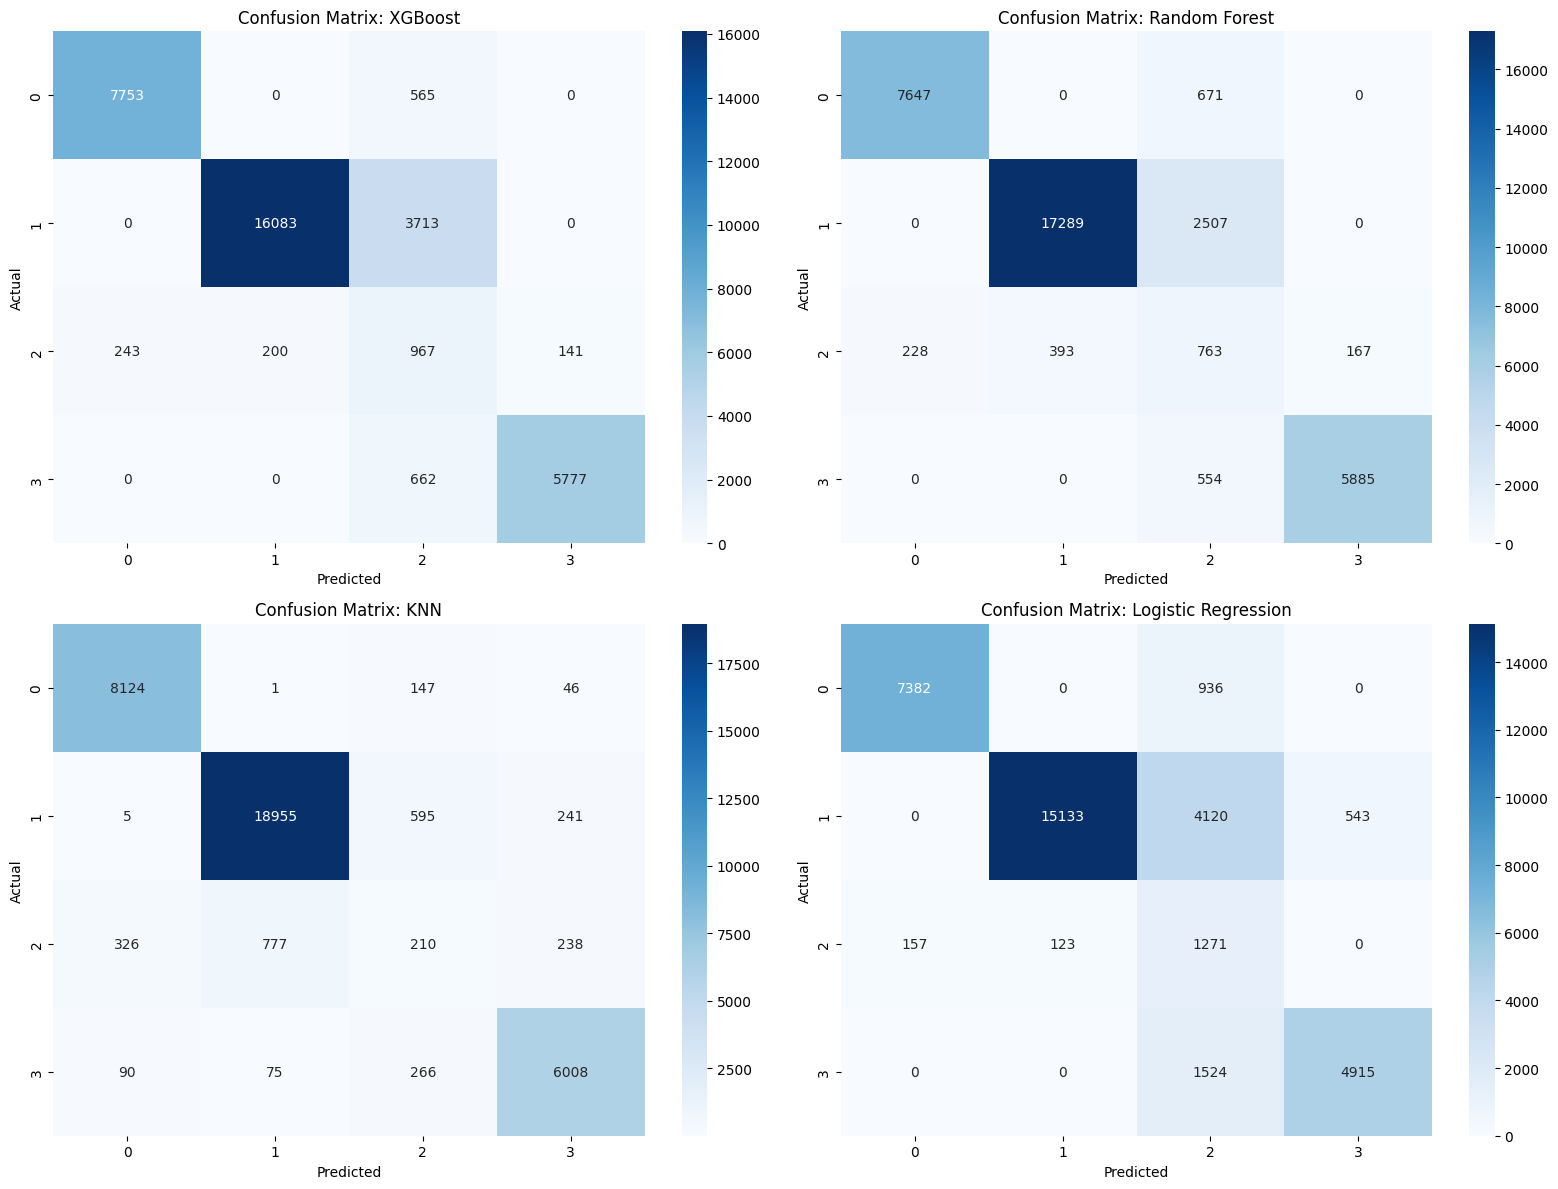

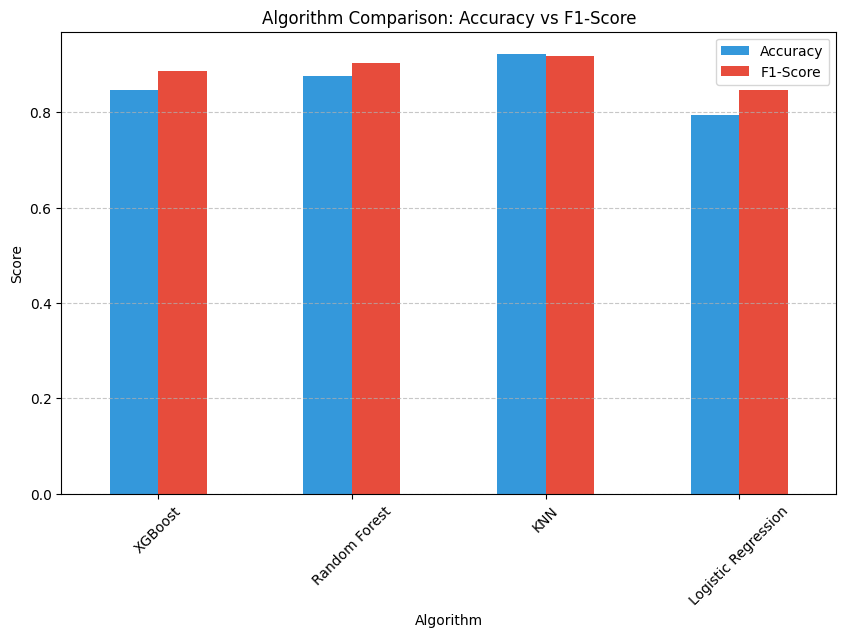

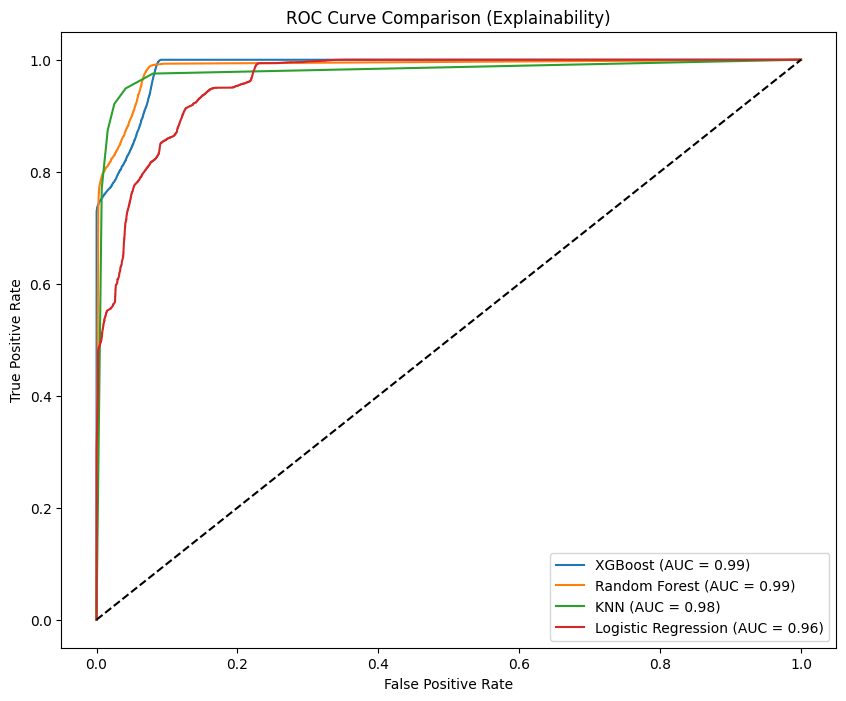

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

# Set up the visualization grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

# 1. Plotting Confusion Matrices for all 4 Models
for i, (name, model) in enumerate(models.items()):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues')
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# 2. Performance Comparison Bar Chart (Accuracy vs F1-Score)
comparison_df.set_index('Algorithm').plot(kind='bar', figsize=(10, 6), color=['#3498db', '#e74c3c'])
plt.title('Algorithm Comparison: Accuracy vs F1-Score')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. Multi-Class ROC Curve (Interpretation)
# Note: This is a bit more advanced and looks great in a report
plt.figure(figsize=(10, 8))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
        # Binarize the output for multi-class ROC
        y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
        # Plotting the macro-average ROC for the algorithm
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Explainability)')
plt.legend()
plt.show()

# CELL 6 — GRADIO DASHBOARD (app.py)

---

**PURPOSE:**

Deploy the trained models as an interactive web application using
Gradio with a real-time agentic intervention system.

---

**HOW IT WORKS:**

The app loads all four saved .pkl model files at startup along with
the label encoder to map numeric predictions back to real class names.
User inputs are passed to the selected model and the prediction is
returned instantly with confidence score and agentic action log.

---

**INPUT PARAMETERS:**

Algorithm              → Select which ML model to use for prediction

Scheduled Shipment Days → How many days the delivery was planned for

Actual vs Scheduled    → Key feature. Positive = late, Negative = early
                         Range is -2 to +4 based on real dataset values

Shipping Mode          → First Class, Same Day, Second Class, Standard

Order Region           → Encoded region value from 0 to 4

Product Price          → Price of the ordered item in USD

Order Quantity         → Number of units in the order

---

**OUTPUT PANELS:**

Status            → Predicted delivery outcome with risk level

Detail            → Confidence score and model accuracy

Agentic Action Log → Automated intervention steps triggered by prediction

Risk Indicator    → Visual bar showing risk intensity

Input Feature Vector → Exact values sent to the model for transparency

---

**DELIVERY OUTCOMES:**

🚨 Late Delivery      → Actual vs Scheduled = +1 to +4, Standard Class

✅ On Time            → Actual vs Scheduled = 0, any mode

⚡ Early Delivery     → Actual vs Scheduled = -1 or -2, First Class

❌ Shipping Canceled  → Rare class, model may not predict this often

---

**PERFORMANCE BENCHMARKS (Real Results):**

KNN                → 92.2% Accuracy  |  F1: 0.91  ← Best Model

Random Forest      → 87.4% Accuracy  |  F1: 0.90

XGBoost            → 84.6% Accuracy  |  F1: 0.88

Logistic Regression → 79.4% Accuracy  |  F1: 0.84

In [ ]:
%%writefile app.py
import gradio as gr
import pandas as pd
import joblib
import os
import numpy as np

# ── Load Models ───────────────────────────────────────────────────────────────
MODELS = {}
for name, fname in [
    ("XGBoost",            "xgboost_model.pkl"),
    ("Random Forest",      "random_forest_model.pkl"),
    ("KNN",                "knn_model.pkl"),
    ("Logistic Regression","logistic_regression_model.pkl"),
]:
    if os.path.exists(fname):
        MODELS[name] = joblib.load(fname)

SHIP_MAP = {"First Class": 0, "Same Day": 1, "Second Class": 2, "Standard Class": 3}

FEATURE_COLS = [
    'Type', 'Days for shipment (scheduled)', 'Shipping Mode',
    'Order Region', 'Order Item Product Price',
    'Order Item Quantity', 'Actual_vs_Scheduled'
]

PERF = {
    "XGBoost":             (84.6,0.88),
    "Random Forest":       (87.4, 0.90),
    "KNN":                 (92.1, 0.91),
    "Logistic Regression": (79.4, 0.84),
}
# Load encoder once at startup
le = joblib.load('label_encoder.pkl') if os.path.exists('label_encoder.pkl') else None

# ── Prediction Logic ──────────────────────────────────────────────────────────
def predict(algo, days_sch, ship_mode, region, price, quantity, actual_vs_sched):
    model = MODELS.get(algo)
    if model is None:
        return (
            "❌  Model Not Loaded",
            "Please re-run the training cell to generate .pkl files.",
            "", "", "", ""
        )

    input_df = pd.DataFrame(
        [[0, days_sch, SHIP_MAP[ship_mode], region, price, quantity, actual_vs_sched]],
        columns=FEATURE_COLS
    )

    if hasattr(model, 'get_booster'):
        input_df = input_df[model.get_booster().feature_names]

    pred  = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0] if hasattr(model, 'predict_proba') else None
    conf  = f"{max(proba)*100:.1f}%" if proba is not None else "N/A"

    acc, f1 = PERF.get(algo, (0, 0))

    # Get real label name from encoder
    label = le.classes_[pred] if le is not None else str(pred)

    if label == 'Late delivery':
        status   = "🚨  HIGH RISK — Late Delivery Predicted"
        detail   = f"Model Confidence: {conf}  |  Algorithm: {algo}  |  Accuracy: {acc}%"
        action   = ("⚡  AGENTIC INTERVENTION TRIGGERED\n\n"
                    "→  Warehouse Priority Flag ........... ACTIVE\n"
                    "→  Customer delay notification ....... DISPATCHED\n"
                    "→  Carrier escalation protocol ....... INITIATED\n"
                    "→  SLA breach alert .................. SENT TO OPS\n\n"
                    f"💡  Recommendation: Add {max(1, actual_vs_sched)} buffer day(s).")
        risk_bar = f"Risk Level: {'█' * min(10, 5 + actual_vs_sched)}{'░' * max(0, 5 - actual_vs_sched)}  HIGH"

    elif label == 'Advance shipping':
        status   = "⚡  EARLY DELIVERY — Arrived Ahead of Schedule"
        detail   = f"Model Confidence: {conf}  |  Algorithm: {algo}  |  Accuracy: {acc}%"
        action   = ("🚀  AGENTIC STATUS: EARLY DELIVERY DETECTED\n\n"
                    "→  Warehouse receiving alert ......... SENT\n"
                    "→  Early arrival notification ........ DISPATCHED\n"
                    "→  Customer notified ................. ACTIVE\n"
                    "→  Storage slot pre-assigned ......... CONFIRMED")
        risk_bar = "Risk Level: ██░░░░░░░░  LOW — EARLY"

    elif label == 'Shipping on time':
        status   = "✅  LOW RISK — On-Time Delivery Expected"
        detail   = f"Model Confidence: {conf}  |  Algorithm: {algo}  |  Accuracy: {acc}%"
        action   = ("🤖  AGENTIC STATUS: NO INTERVENTION REQUIRED\n\n"
                    "→  Standard logistics monitoring ..... ACTIVE\n"
                    "→  SLA compliance .................... WITHIN BOUNDS\n"
                    "→  Carrier status .................... NOMINAL\n"
                    "→  Next checkpoint ................... Pre-dispatch scan")
        risk_bar = "Risk Level: █░░░░░░░░░  LOW"

    elif label == 'Shipping canceled':
        status   = "❌  CANCELLED — Shipment Cancelled"
        detail   = f"Model Confidence: {conf}  |  Algorithm: {algo}  |  Accuracy: {acc}%"
        action   = ("⛔  AGENTIC STATUS: CANCELLATION DETECTED\n\n"
                    "→  Order flagged for review .......... ACTIVE\n"
                    "→  Customer refund initiated ......... PROCESSING\n"
                    "→  Inventory restocked ............... PENDING")
        risk_bar = "Risk Level: ████░░░░░░  CANCELLED"

    else:
        status   = f"ℹ️  Status: {label}"
        detail   = f"Confidence: {conf}  |  Algorithm: {algo}"
        action   = "→  No specific action defined."
        risk_bar = "Risk Level: UNKNOWN"

    feature_summary = (
        f"Type: 0  |  Sched. Days: {days_sch}  |  Mode: {ship_mode} ({SHIP_MAP[ship_mode]})\n"
        f"Region: {region}  |  Price: ${price:.2f}  |  Qty: {quantity}  |  Δ Days: {actual_vs_sched:+d}"
    )

    return status, detail, action, risk_bar, feature_summary, f"F1-Score: {f1}"


# ── Custom CSS ────────────────────────────────────────────────────────────────
CSS = """
@import url('https://fonts.googleapis.com/css2?family=Rajdhani:wght@400;500;600;700&family=Share+Tech+Mono&family=Exo+2:wght@300;400;600;800&display=swap');

:root {
    --bg:       #060a10;
    --panel:    #0c1420;
    --border:   #0f2235;
    --accent:   #00c8ff;
    --warn:     #ff4d00;
    --ok:       #00ff9d;
    --text:     #c8dce8;
    --muted:    #3a5a70;
    --glow:     rgba(0,200,255,0.15);
}

/* ── BASE ── */
body, .gradio-container {
    background: var(--bg) !important;
    font-family: 'Exo 2', sans-serif !important;
    color: var(--text) !important;
}
.gradio-container { max-width: 1200px !important; margin: 0 auto !important; padding: 0 1rem !important; }

/* ── HEADER ── */
.app-header {
    text-align: center;
    padding: 2.5rem 0 1.5rem;
    border-bottom: 1px solid var(--border);
    margin-bottom: 1.5rem;
    position: relative;
}
.app-header::before {
    content: '';
    position: absolute;
    bottom: -1px; left: 50%; transform: translateX(-50%);
    width: 120px; height: 2px;
    background: var(--accent);
    box-shadow: 0 0 20px var(--accent);
}
.app-title {
    font-family: 'Rajdhani', sans-serif !important;
    font-size: 2.8rem !important;
    font-weight: 700 !important;
    color: #fff !important;
    letter-spacing: 0.08em !important;
    text-transform: uppercase !important;
    margin: 0 !important;
    text-shadow: 0 0 40px rgba(0,200,255,0.4);
}
.app-sub {
    font-family: 'Share Tech Mono', monospace !important;
    font-size: 0.75rem !important;
    color: var(--muted) !important;
    letter-spacing: 0.2em !important;
    text-transform: uppercase !important;
    margin-top: 0.5rem !important;
}

/* ── PANELS ── */
.panel {
    background: var(--panel);
    border: 1px solid var(--border);
    border-radius: 4px;
    padding: 1.25rem 1.5rem;
    margin-bottom: 1rem;
    position: relative;
}
.panel::before {
    content: '';
    position: absolute;
    top: 0; left: 0;
    width: 3px; height: 100%;
    background: var(--accent);
}
.panel-label {
    font-family: 'Share Tech Mono', monospace !important;
    font-size: 0.65rem !important;
    color: var(--accent) !important;
    letter-spacing: 0.2em !important;
    text-transform: uppercase !important;
    margin-bottom: 1rem !important;
    display: block;
}

/* ── GRADIO OVERRIDES ── */
.gr-block, .gr-box, .gr-form { background: transparent !important; border: none !important; }
label span, .label-wrap span {
    font-family: 'Share Tech Mono', monospace !important;
    font-size: 0.68rem !important;
    color: var(--muted) !important;
    letter-spacing: 0.12em !important;
    text-transform: uppercase !important;
}
input[type=number], input[type=text], textarea, select,
.gr-input, .gr-text-input {
    background: #080d14 !important;
    border: 1px solid var(--border) !important;
    border-radius: 3px !important;
    color: var(--text) !important;
    font-family: 'Share Tech Mono', monospace !important;
    font-size: 0.85rem !important;
}
input[type=number]:focus, textarea:focus {
    border-color: var(--accent) !important;
    box-shadow: 0 0 0 2px rgba(0,200,255,0.1) !important;
    outline: none !important;
}

/* ── SLIDER ── */
.gr-slider input[type=range] { accent-color: var(--accent) !important; }

/* ── DROPDOWN ── */
.gr-dropdown, select { background: #080d14 !important; }

/* ── BUTTON ── */
button.primary, .gr-button-primary {
    background: transparent !important;
    border: 1px solid var(--accent) !important;
    color: var(--accent) !important;
    font-family: 'Rajdhani', sans-serif !important;
    font-size: 1rem !important;
    font-weight: 600 !important;
    letter-spacing: 0.2em !important;
    text-transform: uppercase !important;
    border-radius: 3px !important;
    padding: 0.75rem 2rem !important;
    transition: all 0.2s !important;
    box-shadow: 0 0 20px rgba(0,200,255,0.1) !important;
    width: 100% !important;
}
button.primary:hover, .gr-button-primary:hover {
    background: rgba(0,200,255,0.1) !important;
    box-shadow: 0 0 30px rgba(0,200,255,0.25) !important;
}

/* ── OUTPUT TEXTBOXES ── */
.gr-text-input textarea, .gr-textbox textarea {
    background: #050810 !important;
    border: 1px solid var(--border) !important;
    color: var(--text) !important;
    font-family: 'Share Tech Mono', monospace !important;
    font-size: 0.82rem !important;
    line-height: 1.8 !important;
    border-radius: 3px !important;
}

/* ── STATUS OUTPUT ── */
#status_out textarea {
    font-family: 'Rajdhani', sans-serif !important;
    font-size: 1.3rem !important;
    font-weight: 600 !important;
    letter-spacing: 0.05em;
    border-left: 3px solid var(--accent) !important;
    padding-left: 1rem !important;
}

/* ── PERFORMANCE TABLE ── */
.perf-grid {
    display: grid;
    grid-template-columns: repeat(4, 1fr);
    gap: 0.75rem;
    margin-top: 0.5rem;
}
.perf-card {
    background: #080d14;
    border: 1px solid var(--border);
    border-radius: 3px;
    padding: 0.75rem 1rem;
    text-align: center;
}
.perf-algo {
    font-family: 'Share Tech Mono', monospace;
    font-size: 0.6rem;
    color: var(--muted);
    letter-spacing: 0.12em;
    text-transform: uppercase;
    margin-bottom: 4px;
}
.perf-acc {
    font-family: 'Rajdhani', sans-serif;
    font-size: 1.6rem;
    font-weight: 700;
    color: #fff;
    line-height: 1;
}
.perf-f1 { font-size: 0.7rem; color: var(--accent); margin-top: 4px; }

/* ── MISC ── */
#component-0 { gap: 0 !important; }
.gap, .gr-padded { padding: 0.5rem !important; }
footer { display: none !important; }
"""

# ── Build UI ──────────────────────────────────────────────────────────────────
with gr.Blocks(css=CSS, title="Supply Chain Risk Intelligence") as app:

    # Header
    gr.HTML("""
    <div class="app-header">
      <div class="app-title">⬡ Supply Chain Risk Intelligence</div>
      <div class="app-sub">DataCo Dataset &nbsp;·&nbsp; SMOTE Balanced &nbsp;·&nbsp; Agentic Intervention System &nbsp;·&nbsp; ML v2.0</div>
    </div>
    """)

    with gr.Row(equal_height=False):

        # ── LEFT: Inputs ──────────────────────────────────────────────────────
        with gr.Column(scale=4):
            gr.HTML('<div class="panel"><span class="panel-label">▸ Model Configuration</span>')
            algo = gr.Dropdown(
                choices=list(MODELS.keys()) if MODELS else ["XGBoost","Random Forest","KNN","Logistic Regression"],
                value="XGBoost", label="Algorithm", container=True
            )
            gr.HTML('</div>')

            gr.HTML('<div class="panel"><span class="panel-label">▸ Order Parameters</span>')
            days = gr.Slider(0, 10, value=3, step=1, label="Scheduled Shipment Days")
            actual_vs_sched = gr.Slider(-2, 4, value=0, step=1,
                                        label="Actual vs Scheduled Days  ( + = late,  − = early )")
            mode = gr.Dropdown(
                choices=["First Class", "Same Day", "Second Class", "Standard Class"],
                value="Standard Class", label="Shipping Mode"
            )
            region  = gr.Slider(0, 4, value=0, step=1, label="Order Region  ( 0 – 4 )")
            price   = gr.Number(value=50.0,  label="Product Price  ($)", precision=2)
            quantity= gr.Number(value=1,     label="Order Quantity",     precision=0)
            gr.HTML('</div>')

            btn = gr.Button("⚡  ANALYZE DELIVERY RISK", variant="primary")

        # ── RIGHT: Outputs ────────────────────────────────────────────────────
        with gr.Column(scale=6):
            gr.HTML('<span class="panel-label" style="font-family:\'Share Tech Mono\',monospace;font-size:0.65rem;color:#00c8ff;letter-spacing:0.2em;text-transform:uppercase;">▸ Prediction Output</span>')
            status_out  = gr.Textbox(label="Status",      lines=2,  elem_id="status_out",  interactive=False)
            detail_out  = gr.Textbox(label="Detail",      lines=1,  interactive=False)
            action_out  = gr.Textbox(label="Agentic Action Log", lines=8, interactive=False)

            with gr.Row():
                risk_out    = gr.Textbox(label="Risk Indicator", lines=1, interactive=False)
                f1_out      = gr.Textbox(label="Model Score",    lines=1, interactive=False)

            feat_out = gr.Textbox(label="Input Feature Vector", lines=2, interactive=False)

    # ── Performance Section ───────────────────────────────────────────────────
    gr.HTML("""
    <div class="panel" style="margin-top:1rem;">
      <span class="panel-label">▸ Algorithm Performance Benchmarks</span>
      <div class="perf-grid">
        <div class="perf-card">
          <div class="perf-algo">XGBoost</div>
          <div class="perf-acc">84.6%</div>
          <div class="perf-f1">F1 · 0.88</div>
        </div>
        <div class="perf-card">
          <div class="perf-algo">Random Forest</div>
          <div class="perf-acc">87.4%</div>
          <div class="perf-f1">F1 · 0.90</div>
        </div>
        <div class="perf-card">
          <div class="perf-algo">KNN</div>
          <div class="perf-acc">92.2%</div>
          <div class="perf-f1">F1 · 0.91</div>
        </div>
        <div class="perf-card">
          <div class="perf-algo">Logistic Regression</div>
          <div class="perf-acc">79.4%</div>
          <div class="perf-f1">F1 · 0.84</div>
        </div>
      </div>
    </div>
    <p style="text-align:center;font-family:'Share Tech Mono',monospace;font-size:0.6rem;color:#1a3550;margin-top:1rem;letter-spacing:0.15em;">
      SUPPLY CHAIN INTELLIGENCE &nbsp;·&nbsp; DATACO DATASET &nbsp;·&nbsp; SMOTE BALANCED &nbsp;·&nbsp; 7 FEATURES
    </p>
    """)

    # ── Wire up button ────────────────────────────────────────────────────────
    btn.click(
        fn=predict,
        inputs=[algo, days, mode, region, price, quantity, actual_vs_sched],
        outputs=[status_out, detail_out, action_out, risk_out, feat_out, f1_out]
    )

app.launch(share=True)

Writing app.py


# CELL 7 — LAUNCH GRADIO APP

---

**PURPOSE:**

Run the Gradio application and generate a public shareable URL
to access the Supply Chain Risk Intelligence dashboard.

---

**HOW IT WORKS:**

Running this cell starts the Gradio server on a local port and
automatically creates a public URL via Gradio's built-in share
feature. No ngrok or localtunnel required.

---

**EXPECTED OUTPUT:**

Running on local URL  →  http://127.0.0.1:7860

Running on public URL →  https://xxxxxx.gradio.live

Open the public URL in any browser to access the dashboard.
The link stays active for 72 hours.

---

**NOTE:**

Keep this cell running while using the app.
Stopping or interrupting this cell will shut down the server.
If the link expires simply re-run this cell to get a new URL.

In [ ]:
!python app.py

/content/app.py:311: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=CSS, title="Supply Chain Risk Intelligence") as app:
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://cf065a6bb52d5077c9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
